# Data Preperation + Model A (baseline)

In this notebook we clean the AID dataset, perform EDA, train/val/test split, construct data pipeline, and the baseline CNN (Model A). 

Classes used (10 out of 30): Forest, Desert, Beach, River, Mountain, DenseResidential, Industrial, Airport, Stadium, Farmland


In [1]:
import os
import sys
import glob
import hashlib
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf

# importing project_utils from the project root
PROJECT_ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)


from project_utils import (
    SEED,
    IMG_SIZE,
    BATCH_SIZE,
    EPOCHS,
    TARGET_CLASSES,
    SPLITS_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    ARTIFACTS_DIR,
    set_seed,
)

set_seed()

REPO_ROOT = PROJECT_ROOT
RAW_DIR = os.path.join(REPO_ROOT, "data", "raw", "AID")

print("Repo root:", REPO_ROOT)
print("Raw data dir:", RAW_DIR)

Repo root: /Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification
Raw data dir: /Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification/data/raw/AID


## 1. EDA

Per-class image counts:
label
River               410
DenseResidential    410
Beach               400
Industrial          390
Farmland            370
Airport             360
Mountain            340
Desert              300
Stadium             290
Forest              250
Name: count, dtype: int64

Balance ratio (largest/smallest) = 410 / 250 = 1.640
Balance constraint satisfied (<= 2x).


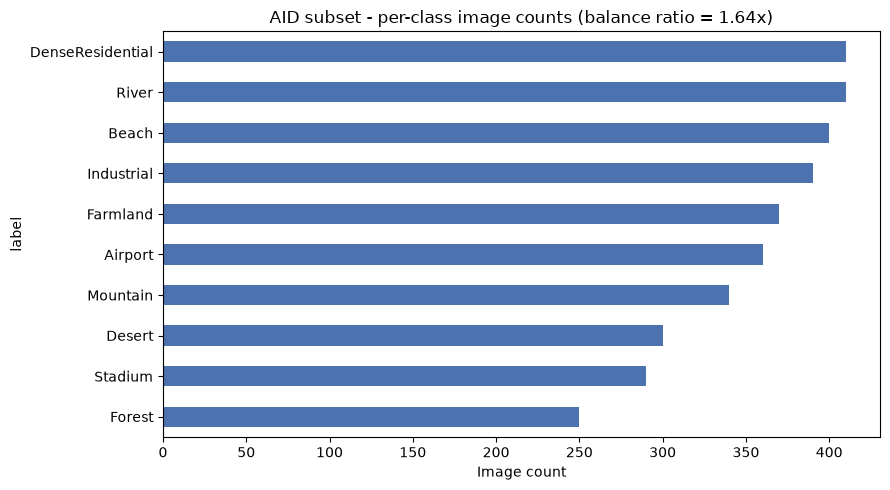

In [2]:
def build_manifest(raw_dir=RAW_DIR, classes=TARGET_CLASSES):
    rows = []
    for label in classes:
        class_dir = os.path.join(raw_dir, label)
        for fname in os.listdir(class_dir):
            rows.append({"filepath": os.path.join(class_dir, fname), "label": label})
    return pd.DataFrame(rows)

manifest = build_manifest()
counts = manifest["label"].value_counts()
print("Per-class image counts:")
print(counts)

balance_ratio = counts.max() / counts.min()
print(f"\nBalance ratio (largest/smallest) = {counts.max()} / {counts.min()} = {balance_ratio:.3f}")
assert balance_ratio <= 2.0
print("Balance constraint satisfied (<= 2x).")

fig, ax = plt.subplots(figsize=(9, 5))
counts.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Image count")
ax.set_title(f"AID subset - per-class image counts (balance ratio = {balance_ratio:.2f}x)")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "class_balance.png"), dpi=120)
plt.show()


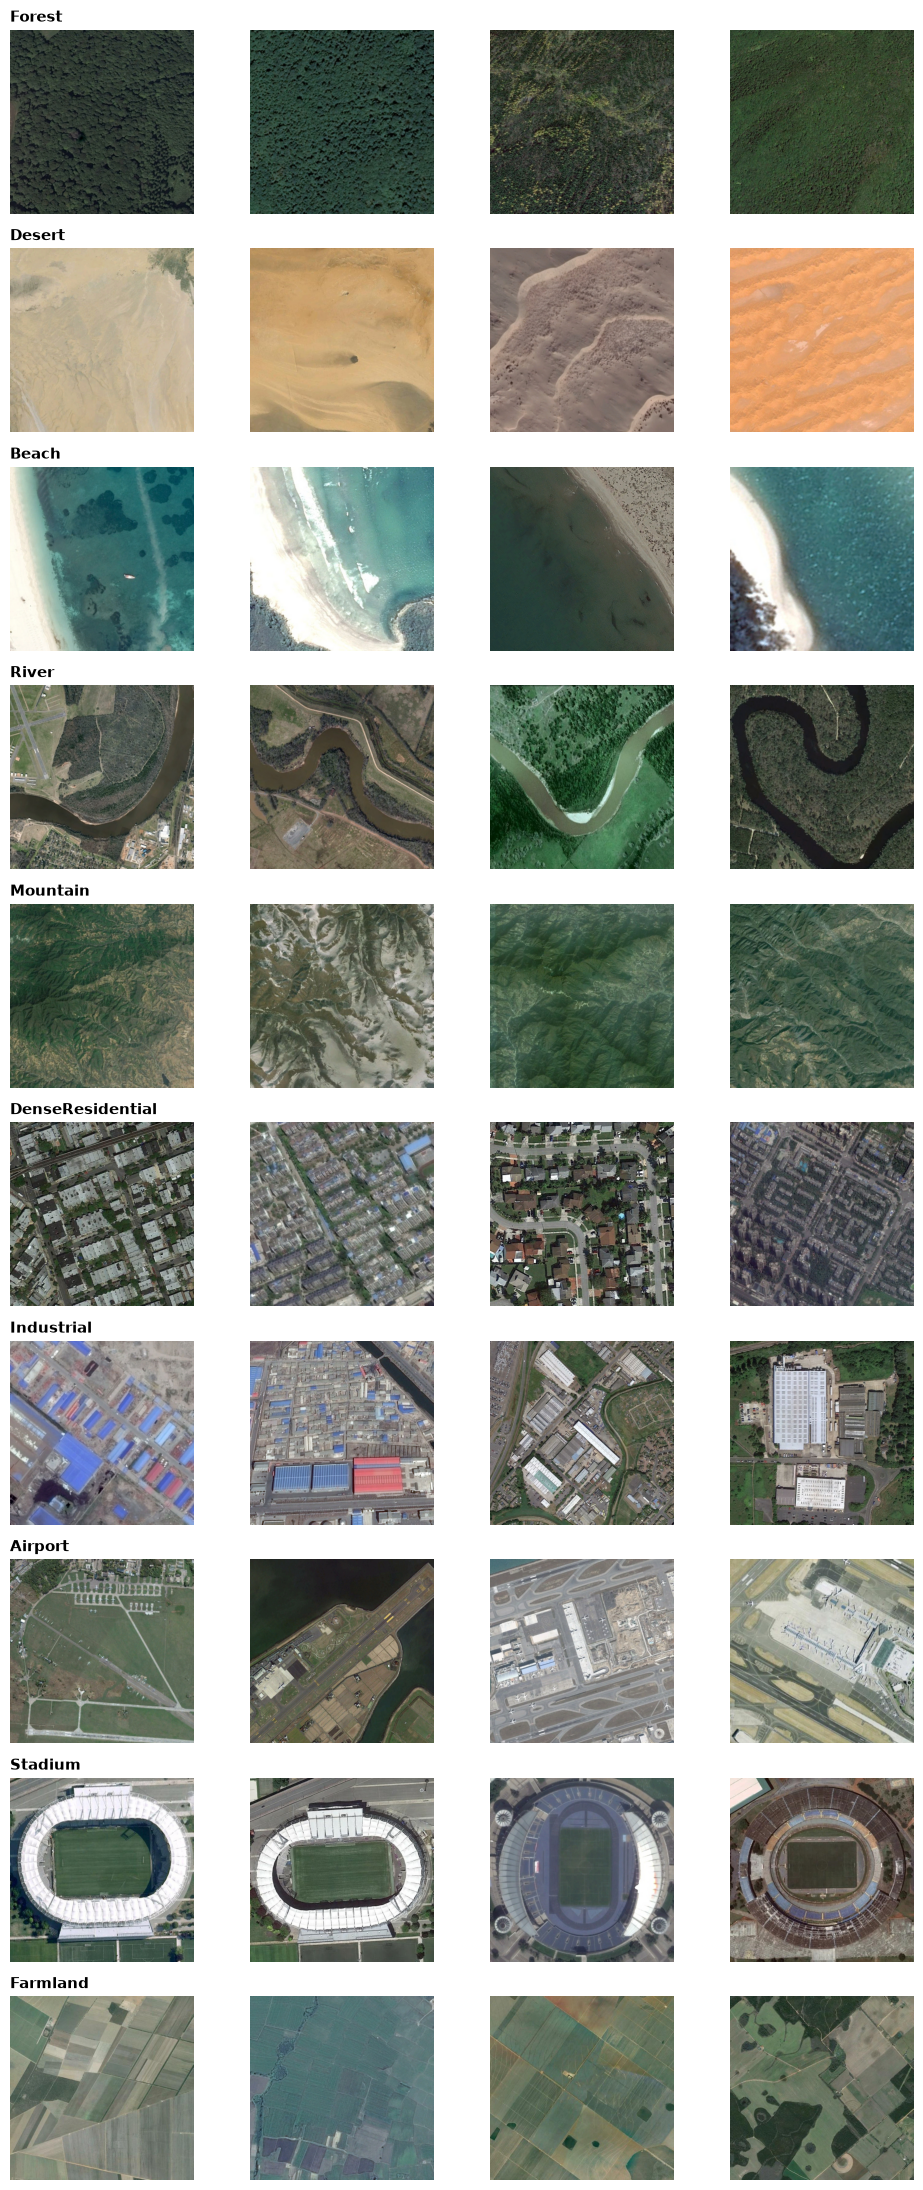

In [3]:
rng = np.random.default_rng(SEED)
fig, axes = plt.subplots(len(TARGET_CLASSES), 4, figsize=(10, 2.2 * len(TARGET_CLASSES)))
for i, label in enumerate(TARGET_CLASSES):
    class_files = manifest.loc[manifest["label"] == label, "filepath"].tolist()
    sample = rng.choice(class_files, size=4, replace=False)
    for j, fp in enumerate(sample):
        img = Image.open(fp)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(label, fontsize=10)
    axes[i, 0].set_title(label, loc="left", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "sample_grid.png"), dpi=120)
plt.show()


In [4]:
def audit_images(df):
    widths, heights, formats, corrupted = [], [], [], []
    for path in df["filepath"]:
        try:
            with Image.open(path) as img:
                img.verify()
            with Image.open(path) as img:
                w, h = img.size
                fmt = img.format
            widths.append(w); heights.append(h); formats.append(fmt); corrupted.append(False)
        except Exception:
            widths.append(None); heights.append(None); formats.append(None); corrupted.append(True)
    out = df.copy()
    out["width"], out["height"], out["format"], out["corrupted"] = widths, heights, formats, corrupted
    return out

audited = audit_images(manifest)
n_corrupt = int(audited["corrupted"].sum())
print("Corrupted / unreadable files:", n_corrupt)

dim_mismatch = audited[(audited["width"] != 600) | (audited["height"] != 600)]
print("Files not exactly 600x600:", len(dim_mismatch))

print("\nContent format counts (by actual file signature, not extension):")
print(audited["format"].value_counts(dropna=False))

fmt_mismatch = audited[audited["format"] != "JPEG"]
if len(fmt_mismatch):
    print(f"\nNote: {len(fmt_mismatch)} files are named .jpg but are actually "
          f"{fmt_mismatch['format'].unique().tolist()} internally -- "
          f"all in class(es): {fmt_mismatch['label'].unique().tolist()}. "
          "The loading pipeline below uses tf.io.decode_image (format-agnostic) "
          "instead of decode_jpeg specifically to handle this safely.")


Corrupted / unreadable files: 0
Files not exactly 600x600: 0

Content format counts (by actual file signature, not extension):
format
JPEG    3439
PNG       81
Name: count, dtype: int64

Note: 81 files are named .jpg but are actually ['PNG'] internally -- all in class(es): ['DenseResidential']. The loading pipeline below uses tf.io.decode_image (format-agnostic) instead of decode_jpeg specifically to handle this safely.


## 2. Cleaning
Drop corrupted files and exact duplicates.

In [5]:
def find_duplicates(df):
    hashes = {}
    is_dup = []
    for path in df["filepath"]:
        with open(path, "rb") as f:
            h = hashlib.md5(f.read()).hexdigest()
        is_dup.append(h in hashes)
        hashes.setdefault(h, path)
    return pd.Series(is_dup, index=df.index)

clean = audited[~audited["corrupted"]].copy()
dup_mask = find_duplicates(clean)
n_dupes = int(dup_mask.sum())
clean = clean[~dup_mask].reset_index(drop=True)

print(f"Dropped {n_corrupt} corrupted + {n_dupes} duplicate files.")
print("Final clean dataset size:", len(clean))
print(clean["label"].value_counts())

clean_ratio = clean["label"].value_counts().max() / clean["label"].value_counts().min()
print(f"Balance ratio after cleaning: {clean_ratio:.3f}")

clean["filepath"] = clean["filepath"].apply(lambda p: os.path.relpath(p, REPO_ROOT).replace("\\", "/"))
clean[["filepath", "label"]].to_csv(os.path.join(SPLITS_DIR, "clean_manifest.csv"), index=False)


Dropped 0 corrupted + 0 duplicate files.
Final clean dataset size: 3520
label
River               410
DenseResidential    410
Beach               400
Industrial          390
Farmland            370
Airport             360
Mountain            340
Desert              300
Stadium             290
Forest              250
Name: count, dtype: int64
Balance ratio after cleaning: 1.640


## 3. Train/val/test split (70/15/15, seed=42)

In [6]:
train_df, temp_df = train_test_split(
    clean, test_size=0.30, stratify=clean["label"], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=SEED
)
train_df = train_df.assign(split="train")
val_df = val_df.assign(split="val")
test_df = test_df.assign(split="test")

print("Train:", len(train_df), "| Val:", len(val_df), "| Test:", len(test_df))

all_paths = pd.concat([train_df["filepath"], val_df["filepath"], test_df["filepath"]])
assert all_paths.is_unique
print("No leakage: every image appears in exactly one split.")

cols = ["filepath", "label", "split"]
train_df[cols].to_csv(os.path.join(SPLITS_DIR, "train.csv"), index=False)
val_df[cols].to_csv(os.path.join(SPLITS_DIR, "val.csv"), index=False)
test_df[cols].to_csv(os.path.join(SPLITS_DIR, "test.csv"), index=False)
print("Saved train.csv / val.csv / test.csv to", SPLITS_DIR)


Train: 2464 | Val: 528 | Test: 528
No leakage: every image appears in exactly one split.
Saved train.csv / val.csv / test.csv to /Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification/data/splits


## 4. Data pipeline
Resize, batch, shuffle (train only), and prefetch.

In [7]:
from project_utils import load_datasets

train_ds, val_ds, test_ds = load_datasets()

for imgs, labels in train_ds.take(1):
    print("Batch image shape:", imgs.shape, "| dtype:", imgs.dtype)
    print("Batch label shape:", labels.shape)

Batch image shape: (32, 160, 160, 3) | dtype: <dtype: 'float32'>
Batch label shape: (32,)


## 5. Model A - baseline CNN
Simple version: 2 conv blocks, no BatchNorm/Dropout/Augmentation.

In [8]:
from project_utils import build_cnn

model_a_config = {
    "name": "model_a_baseline",
    "filters": [32, 64],
    "kernel_size": 3,
    "augmentation": False,
    "batch_norm": False,
    "dense_units": 64,
    "dropout": 0.0
}

model_a = build_cnn(
    num_classes=len(TARGET_CLASSES),
    config=model_a_config
)

model_a.summary()

n_params = model_a.count_params()
print(f"\nTotal parameters: {n_params:,}")

Model: "model_a_baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,202 (94.54 KB)

 Trainable params: 24,202 (94.54 KB)

 Non-trainable params: 0 (0.00 B)


Total parameters: 24,202


In [9]:
model_a.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

start = time.time()

history = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=2
)

train_time_sec = time.time() - start
print(f"\nTraining time: {train_time_sec:.1f} sec for {EPOCHS} epochs")

Epoch 1/15


/Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification/.venv/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


77/77 - 10s - 134ms/step - accuracy: 0.1814 - loss: 2.1174 - val_accuracy: 0.2765 - val_loss: 1.8815
Epoch 2/15
77/77 - 10s - 130ms/step - accuracy: 0.4038 - loss: 1.6830 - val_accuracy: 0.4489 - val_loss: 1.5580
Epoch 3/15
77/77 - 10s - 133ms/step - accuracy: 0.4692 - loss: 1.4672 - val_accuracy: 0.4867 - val_loss: 1.4225
Epoch 4/15
77/77 - 10s - 134ms/step - accuracy: 0.4915 - loss: 1.3730 - val_accuracy: 0.4886 - val_loss: 1.4131
Epoch 5/15
77/77 - 10s - 135ms/step - accuracy: 0.4911 - loss: 1.3655 - val_accuracy: 0.5133 - val_loss: 1.3089
Epoch 6/15
77/77 - 11s - 136ms/step - accuracy: 0.5304 - loss: 1.2796 - val_accuracy: 0.5322 - val_loss: 1.2515
Epoch 7/15
77/77 - 11s - 136ms/step - accuracy: 0.5037 - loss: 1.3098 - val_accuracy: 0.5322 - val_loss: 1.2332
Epoch 8/15
77/77 - 11s - 137ms/step - accuracy: 0.5479 - loss: 1.2502 - val_accuracy: 0.5227 - val_loss: 1.2381
Epoch 9/15
77/77 - 11s - 140ms/step - accuracy: 0.5641 - loss: 1.2146 - val_accuracy: 0.5322 - val_loss: 1.2074
Epo

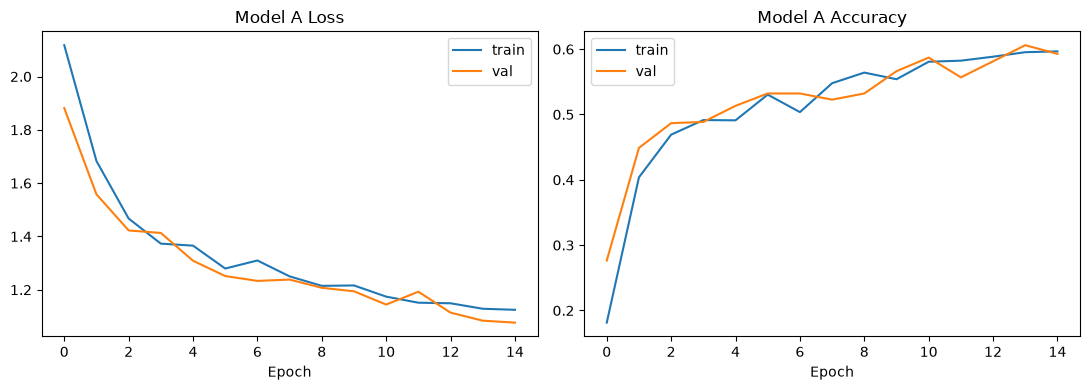

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history.history["loss"], label="train")
axes[0].plot(history.history["val_loss"], label="val")
axes[0].set_title("Model A Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train")
axes[1].plot(history.history["val_accuracy"], label="val")
axes[1].set_title("Model A Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_a_curves.png"), dpi=120)
plt.show()

Model A test accuracy: 0.6364 | test loss: 1.0350


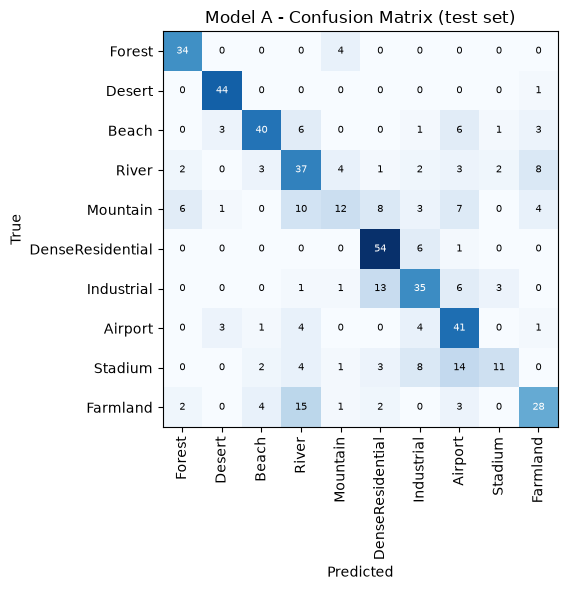

                  precision    recall  f1-score   support

          Forest       0.77      0.89      0.83        38
          Desert       0.86      0.98      0.92        45
           Beach       0.80      0.67      0.73        60
           River       0.48      0.60      0.53        62
        Mountain       0.52      0.24      0.32        51
DenseResidential       0.67      0.89      0.76        61
      Industrial       0.59      0.59      0.59        59
         Airport       0.51      0.76      0.61        54
         Stadium       0.65      0.26      0.37        43
        Farmland       0.62      0.51      0.56        55

        accuracy                           0.64       528
       macro avg       0.65      0.64      0.62       528
    weighted avg       0.64      0.64      0.62       528



In [11]:
test_loss, test_acc = model_a.evaluate(test_ds, verbose=0)
print(f"Model A test accuracy: {test_acc:.4f} | test loss: {test_loss:.4f}")

y_true, y_pred = [], []
for imgs, labels in test_ds:
    probs = model_a.predict(imgs, verbose=0)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(np.argmax(probs, axis=1).tolist())

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(TARGET_CLASSES))); ax.set_xticklabels(TARGET_CLASSES, rotation=90)
ax.set_yticks(range(len(TARGET_CLASSES))); ax.set_yticklabels(TARGET_CLASSES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("Model A - Confusion Matrix (test set)")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "model_a_confusion_matrix.png"), dpi=120)
plt.show()

print(classification_report(y_true, y_pred, target_names=TARGET_CLASSES))


In [12]:
model_a.save(
    os.path.join(ARTIFACTS_DIR, "model_a_baseline.keras")
)

history_out = {
    "model": "model_a_baseline",
    "config": model_a_config,
    "epochs": EPOCHS,
    "train_time_sec": float(train_time_sec),
    "n_params": int(n_params),
    "test_accuracy": float(test_acc),
    "test_loss": float(test_loss),
    "history": {
        k: [float(v) for v in vals]
        for k, vals in history.history.items()
    },
}

with open(
    os.path.join(RESULTS_DIR, "model_a_history.json"),
    "w"
) as f:
    json.dump(history_out, f, indent=2)


print(
    "Saved model to",
    os.path.join(ARTIFACTS_DIR, "model_a_baseline.keras")
)

print(
    "Saved training history to",
    os.path.join(RESULTS_DIR, "model_a_history.json")
)

Saved model to /Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification/artifacts/model_a_baseline.keras
Saved training history to /Users/joudalrubaish/Tuwaiq-AI /AID-Scene_Classification/results/model_a_history.json


## Recap

- 10 classes kept, other 20 removed from data/raw/AID
- EDA + plots saved in results/figures
- corrupted/duplicate check done, clean list saved in data/splits/clean_manifest.csv
- 70/15/15 split saved as csv, checked for leakage
- data pipeline function in this notebook (resize/batch/shuffle/prefetch)
- Model A trained and saved to artifacts/model_a_baseline_updated.keras, history in results/model_a_updated_history.json

## Findings
The baseline CNN achieved a test accuracy of 63.64% and a macro F1-score of 0.62. The very small difference between training and validation accuracy indicates that the model does not suffer from overfitting. However, the relatively moderate accuracy suggests underfitting, particularly for visually complex classes such as Mountain and Stadium. Therefore, Model B will increase the network depth and progressively scale the filters from 32 to 64 to 128 to test whether deeper feature extraction improves classification performance. 
